In [21]:
from sklearn.decomposition import PCA
import sys
import pickle
import os
import matplotlib.pyplot as plt
sys.path.append('..')
from utils.config import results_dir, data_dir
from ml_pipelines.run_ml_pipe import load_and_preprocess_features, get_clean_features, get_columns_for_feature

In [38]:
df = load_and_preprocess_features("adolescent")

2025-02-27 13:06:21 [INFO] Running analysis for adolescent group.
/Users/hamzaabdelhedi/Projects/EEG_psychostim/EEG_psychostimulant_github/plot/../ml_pipelines/run_ml_pipe.py:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features["group"] = features["group"].replace({"PAT": 1, "CTR": 0})


In [39]:
# load results 
with open(os.path.join(results_dir , "unsupervised_single_feature_all_sensors_adolescent.pkl"), "rb") as f:
    results = pickle.load(f)

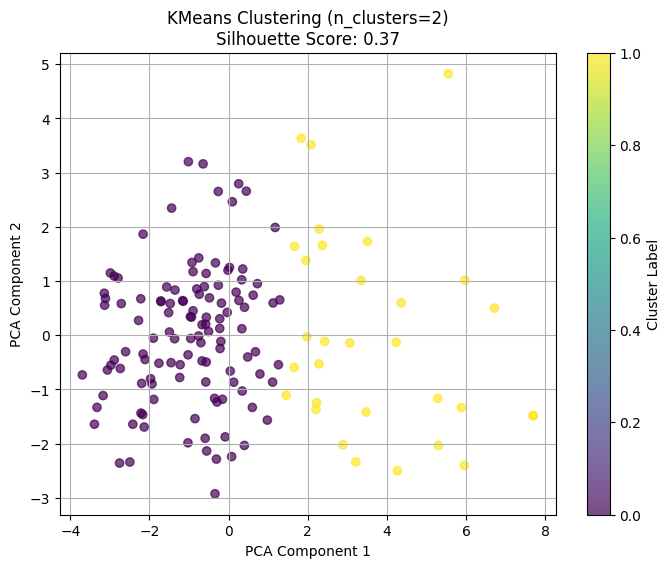

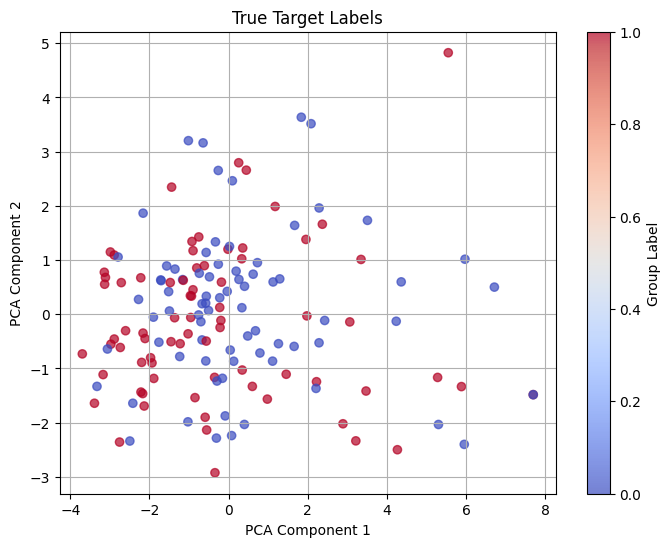

In [40]:
k = 2
df
columns = df.columns[1:]

X_processed = df.drop(columns=["group"]).values
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

cluster_labels = results[k]["cluster_labels"]
silhouette_avg = results[k]["silhouette"]

# Plot clusters using the first two PCA components in one figure.
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"KMeans Clustering (n_clusters={k})\nSilhouette Score: {silhouette_avg:.2f}")
plt.colorbar(scatter, label="Cluster Label")
plt.grid(True)
plt.show()

# Plot the true target labels from 'data' in a separate figure.
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['group'], cmap="coolwarm", alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("True Target Labels")
plt.colorbar(scatter, label="Group Label")
plt.grid(True)
plt.show()
